Importing Data


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import random

In [80]:
fashion_train_df = pd.read_csv("input/fashion-mnist_train.csv", sep = ",")

In [81]:
fashion_test_df = pd.read_csv("input/fashion-mnist_train.csv", sep = ",")

Vizulazation

In [82]:
fashion_train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [83]:
fashion_train_df.tail()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59999,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [84]:
fashion_test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [85]:
fashion_test_df.tail()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59999,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [86]:
fashion_train_df.shape

(60000, 785)

In [87]:
fashion_test_df.shape

(60000, 785)

In [88]:
training = np.array(fashion_train_df, dtype= "float32")

In [89]:
training = np.array(fashion_test_df, dtype= "float32")

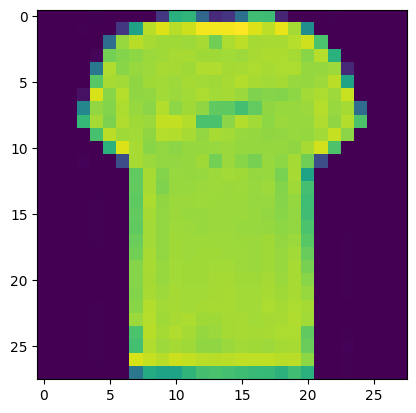

In [90]:
plt.imshow(training[10, 1:].reshape(28, 28))

np.float32(1.0)

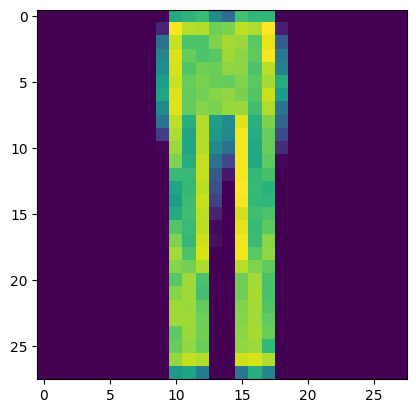

In [91]:
i = random.randint(1,60000)
plt.imshow(training[i, 1:].reshape(28, 28))
label = training[i, 0]
label

In [92]:
# Remember the 10 classes decoding is as follows:
# 0 - T-shirt/top
# 1 - Trouser
# 2 - Pullover
# 3 - Dress
# 4 - Coat
# 5 - Sandal
# 6 - Shirt
# 7 - Sneaker
# 8 - Bag
# 9 - Ankle boot


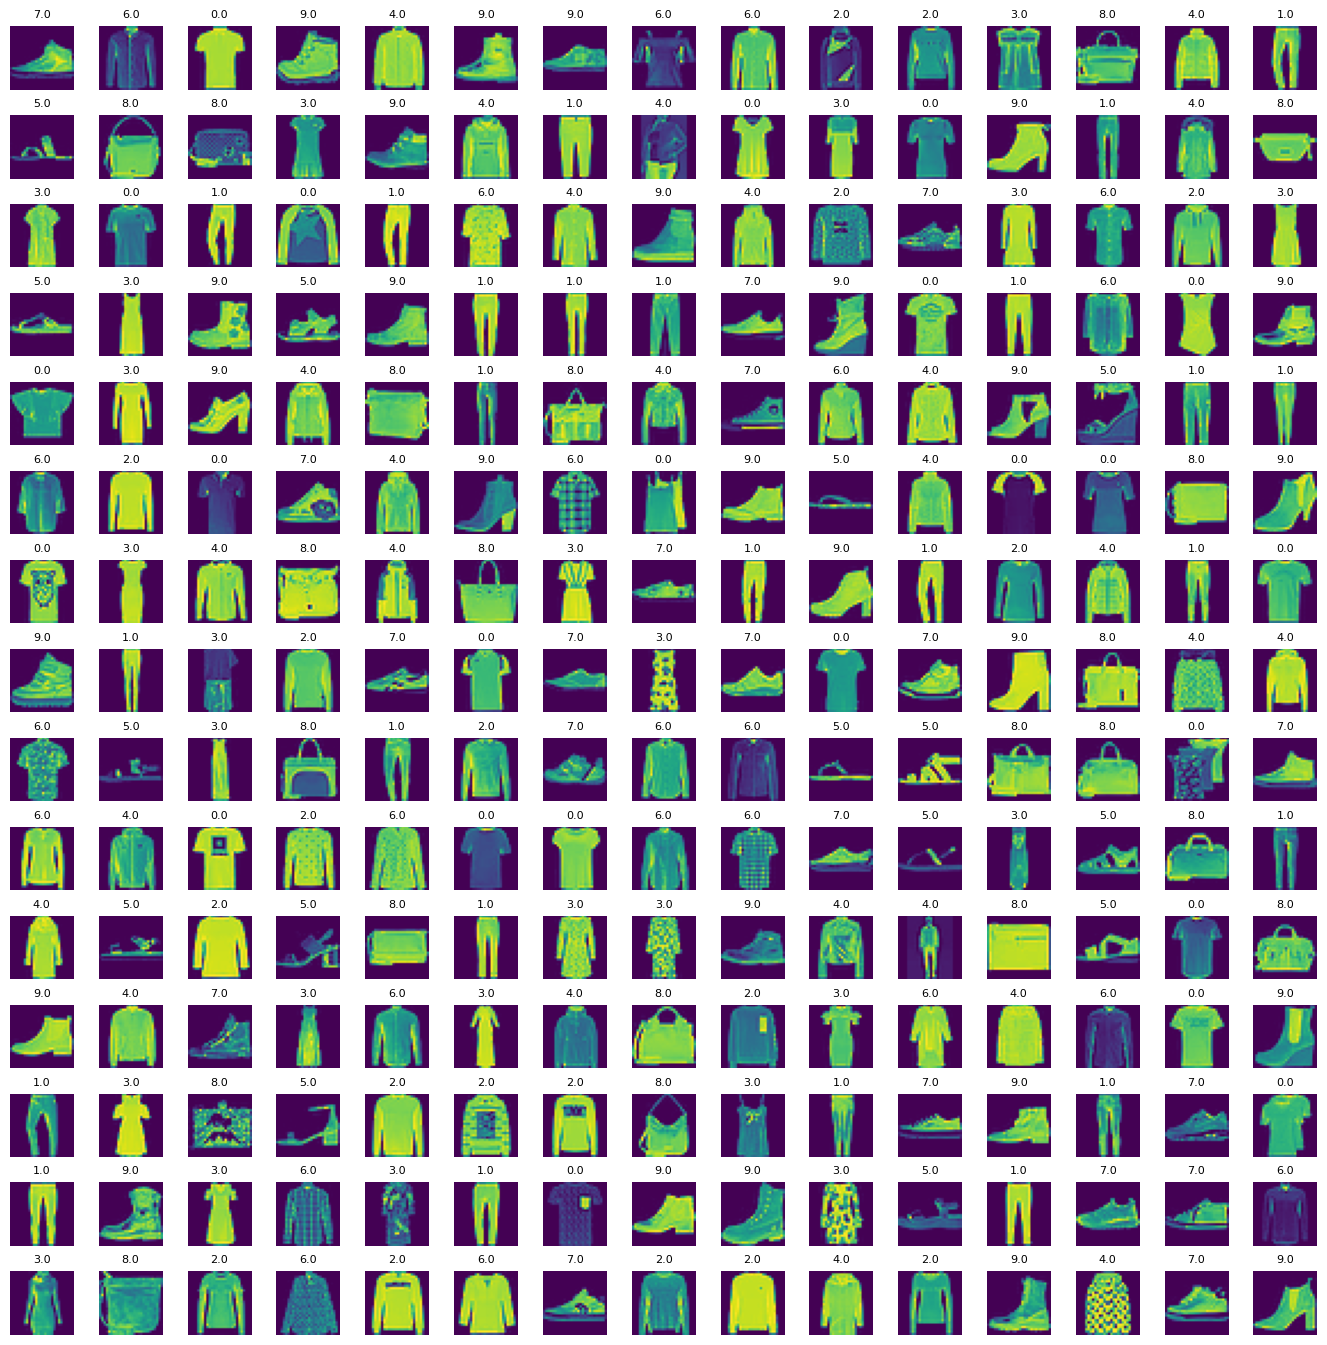

In [93]:
# Let's view more images in a grid format
# Define the dimensions of the plot grid
W_grid = 15
L_grid = 15

# fig, axes = plt.subplots(L_grid, W_grid)
# subplot return the figure object and axes object
# we can use the axes object to plot specific figures at various locations

fig, axes = plt.subplots(L_grid, W_grid, figsize = (17,17))

axes = axes.ravel()  # flatten the 15 x 15 matrix into 225 array

n_training = len(training)  # get the length of the training dataset

# Select a random number from 0 to n_training
for i in np.arange(0, W_grid * L_grid):  # create evenly spaces variables
    
    # Select a random number
    index = np.random.randint(0, n_training)
    
    # read and display an image with the selected index
    axes[i].imshow(training[index,1:].reshape(28,28))
    axes[i].set_title(training[index,0], fontsize = 8)
    axes[i].axis('off')

plt.subplots_adjust(hspace = 0.4)

Model Training

In [94]:
X_train = training[:, 1:]/255
y_train = training[:, 0]

In [99]:
testing = np.array(fashion_test_df, dtype="float32")

X_test = testing[:, 1:]/255
y_test = testing[:, 0]

In [102]:
%pip install scikit-learn

from sklearn.model_selection import train_test_split

Note: you may need to restart the kernel to use updated packages.


In [105]:
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train, test_size=0.33, random_state=12345)

In [107]:
X_train = X_train.reshape(X_train.shape[0], *(28,28,1))
X_test = X_test.reshape(X_test.shape[0], *(28,28,1))
X_validate = X_validate.reshape(X_validate.shape[0], *(28,28,1))


In [108]:
X_train.shape

(26934, 28, 28, 1)

In [109]:
X_test.shape

(19800, 28, 28, 1)

In [111]:
X_validate.shape

(13266, 28, 28, 1)

In [113]:
import keras

In [114]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from keras.optimizers import Adam
from keras.callbacks import TensorBoard

In [115]:
cnn_model = Sequential()

In [117]:
cnn_model.add(Conv2D(32,3,3, input_shape = (28,28,1), activation = 'relu'))

c:\Users\ASHUTOSH SAHU\OneDrive\Desktop\FashionClass\env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [118]:
cnn_model.add(MaxPooling2D(pool_size = (2,2)))

In [119]:
cnn_model.add(Flatten())

In [124]:
cnn_model.add(Dense(units=32, activation='relu'))

In [125]:
cnn_model.add(Dense(units = 10, activation='sigmoid'))

In [126]:
cnn_model.compile(loss = 'sparse_categorical_crossentropy', optimizer = Adam(), metrics = ['accuracy'])

In [127]:
epochs = 50

In [131]:
cnn_model.fit(X_train, y_train, batch_size = 512, epochs = epochs, validation_data = (X_validate, y_validate))

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3372 - loss: 3.9577 - val_accuracy: 0.3025 - val_loss: 3.3160
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1317 - loss: 2.3965 - val_accuracy: 0.1021 - val_loss: 2.3022
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0998 - loss: 2.3032 - val_accuracy: 0.1022 - val_loss: 2.3019
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0998 - loss: 2.3031 - val_accuracy: 0.1021 - val_loss: 2.3022
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0998 - loss: 2.3028 - val_accuracy: 0.1021 - val_loss: 2.3022
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0998 - loss: 2.3028 - val_accuracy: 0.1021 - val_loss: 2.3022
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0998 - loss: 2.3025 - val_accuracy: 0.1021 - val_loss: 2.3022
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0998 - loss: 2.3025 - val_accuracy: 0.1021 - va

Evaluating The Model

In [132]:
evaluation = cnn_model.evaluate(X_test, y_test)
print('Test Accuracy : {:.3f}'.format(evaluation[1]))

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0992 - loss: 2.3021
Test Accuracy : 0.099


In [134]:
predicted_classes = cnn_model.predict(X_test)

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 933us/step


In [135]:
predicted_classes

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(19800, 10), dtype=float32)

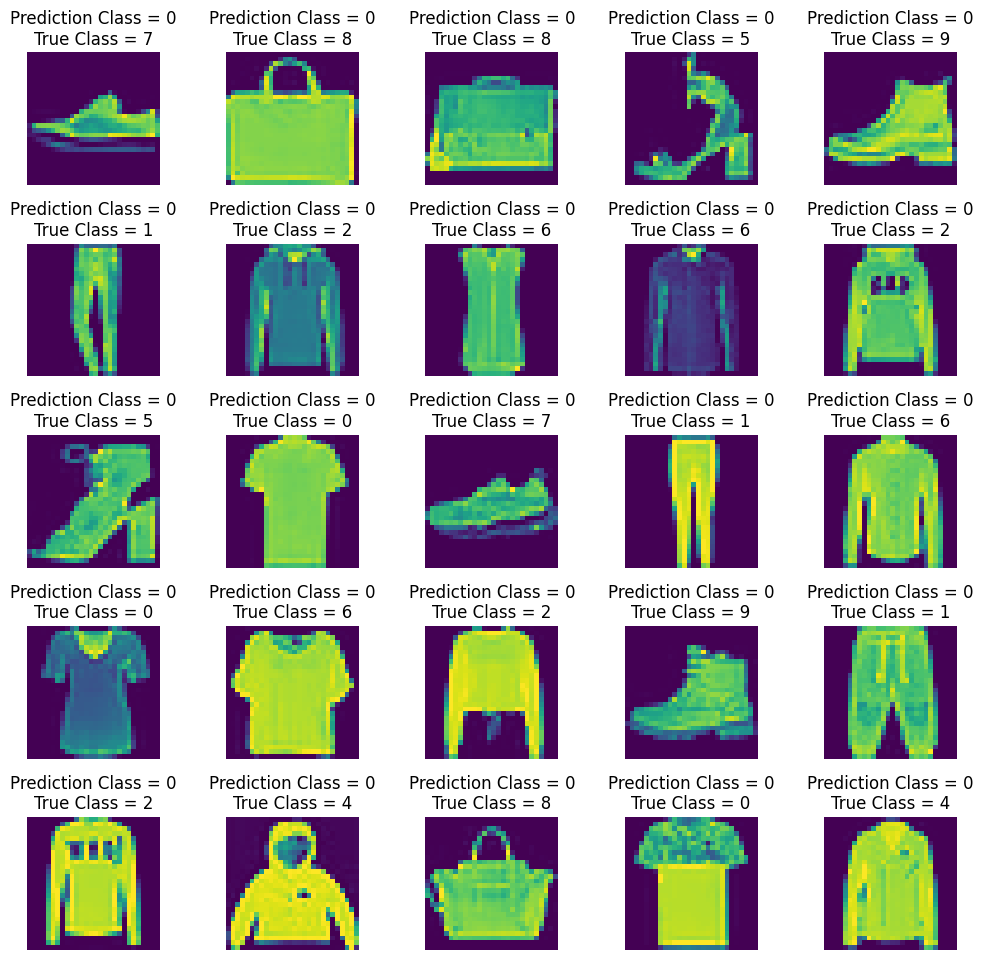

In [143]:
L = 5
W = 5
fig, axes = plt.subplots(L, W, figsize=(12,12))
axes = axes.ravel()

for i in np.arange(0, L * W):
    axes[i].imshow(X_test[i].reshape(28,28))
    predicted_label = np.argmax(predicted_classes[i])
    axes[i].set_title(f"Prediction Class = {predicted_label}\nTrue Class = {int(y_test[i])}")
    axes[i].axis('off')

plt.subplots_adjust(wspace=0.5)

In [ ]:
from sklearn.metrics import confusion_matrix

predicted_labels = np.argmax(predicted_classes, axis=1)
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(14,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

ValueError: Classification metrics can't handle a mix of multiclass and continuous-multioutput targets